# 06 — Departure Regression (V9.0)


In [1]:
# 0. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve
)
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import catboost as cb
import lightgbm as lgb
import shap
import joblib
import json
import os
import sys

# === Project paths (RCF: only change BASE_DIR) ===
BASE_DIR = Path('../../..')             # RCF: Path('/path/to/project')
if not (BASE_DIR / 'src').exists():
    BASE_DIR = Path('../../..')

DATA_RAW = BASE_DIR / 'data' / 'raw' / 'LGA_Dataset'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Add src to path
sys.path.insert(0, str(BASE_DIR / 'src'))

from features.lag_features import add_lag_features, add_congestion_features, compute_v4_lag_features
from features.aircraft_features import compute_prev_aircraft_delay
from models.calibration import (
    fit_isotonic_calibration, apply_calibration, compute_ece
)
from models.temporal_weights import compute_temporal_weights, combine_temporal_and_class_weights

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 1. Load Data from NB03

In [2]:
# === Load model context from 03 ===
import pickle
ctx = pickle.load(open(DATA_PROCESSED / 'dep_baseline_context.pkl', 'rb'))

feature_columns = ctx['feature_columns']
X_train = ctx['X_train']; X_test = ctx['X_test']
y_train = ctx['y_train']; y_test = ctx['y_test']
train = ctx['train']; test = ctx['test']
train_medians = ctx['train_medians']

# Regression targets
y_train_reg = train['Dep_Calculated_Delay'].copy()
y_test_reg = test['Dep_Calculated_Delay'].copy()

print(f'Loaded dep_model_context: {len(feature_columns)} features')
print(f'  X_train={X_train.shape}, y_train_reg range=[{y_train_reg.min():.0f}, {y_train_reg.max():.0f}]')

Loaded dep_model_context: 23 features
  X_train=(104460, 23), y_train_reg range=[-94, 2590]


## 2. RMSE Model (CatBoost Optuna)

In [3]:
# 1. CatBoost RMSE Optuna (100 trials)

def objective_regression(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 6, 14),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 50, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'random_seed': SEED,
        'verbose': 0,
        'loss_function': 'RMSE',
    }
    
    model = cb.CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_reg,
        eval_set=(X_test, y_test_reg),
        early_stopping_rounds=50,
        verbose=0
    )
    
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    
    trial.set_user_attr('mae', mae)
    trial.set_user_attr('r2', r2)
    trial.set_user_attr('best_iteration', model.best_iteration_)
    
    return rmse

print('Starting RMSE Optuna (100 trials)...')
study_rmse = optuna.create_study(direction='minimize', study_name='dep_rmse')
study_rmse.optimize(objective_regression, n_trials=100, show_progress_bar=True)

best_trial = study_rmse.best_trial
print(f'\nBest RMSE: {study_rmse.best_value:.2f}')
print(f'Best MAE:  {best_trial.user_attrs["mae"]:.2f}')
print(f'Best R²:   {best_trial.user_attrs["r2"]:.4f}')
print(f'Best params: {study_rmse.best_params}')

Starting RMSE Optuna (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


Best RMSE: 40.57
Best MAE:  14.63
Best R²:   0.4011
Best params: {'iterations': 625, 'depth': 9, 'learning_rate': 0.07853802958743879, 'l2_leaf_reg': 40.64705923218715, 'subsample': 0.6286791850885748, 'colsample_bylevel': 0.8615259998717482, 'min_data_in_leaf': 17}


## 3. Quantile Models

In [4]:
# 2. Quantile regression: Q05, Q10, Q50, Q90, Q95 (50 trials each)

quantiles = [0.05, 0.10, 0.50, 0.90, 0.95]
quantile_models = {}
quantile_preds = {}

for alpha in quantiles:
    q_name = f'Q{int(alpha*100):02d}'
    print(f'\n--- {q_name} (alpha={alpha}) ---')
    
    def objective_quantile(trial, _alpha=alpha):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 800),
            'depth': trial.suggest_int('depth', 6, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 50, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_seed': SEED,
            'verbose': 0,
            'loss_function': f'Quantile:alpha={_alpha}',
        }
        
        model = cb.CatBoostRegressor(**params)
        model.fit(X_train, y_train_reg, eval_set=(X_test, y_test_reg),
                  early_stopping_rounds=50, verbose=0)
        
        preds = model.predict(X_test)
        errors = y_test_reg.values - preds
        pinball = np.mean(np.where(errors >= 0, _alpha * errors, (_alpha - 1) * errors))
        
        trial.set_user_attr('mae', mean_absolute_error(y_test_reg, preds))
        return pinball
    
    study_q = optuna.create_study(direction='minimize', study_name=f'dep_{q_name}')
    study_q.optimize(objective_quantile, n_trials=50, show_progress_bar=True)
    
    # Train best model
    best_p = study_q.best_params.copy()
    best_p['random_seed'] = SEED
    best_p['verbose'] = 0
    best_p['loss_function'] = f'Quantile:alpha={alpha}'
    
    q_model = cb.CatBoostRegressor(**best_p)
    q_model.fit(X_train, y_train_reg, eval_set=(X_test, y_test_reg),
                early_stopping_rounds=50, verbose=0)
    
    preds = q_model.predict(X_test)
    mae = mean_absolute_error(y_test_reg, preds)
    print(f'  Best MAE: {mae:.2f} min')
    
    quantile_models[q_name] = q_model
    quantile_preds[q_name] = preds

# Summary
print('\n=== Quantile Summary ===')
for q_name, preds in quantile_preds.items():
    mae = mean_absolute_error(y_test_reg, preds)
    print(f'  {q_name}: MAE={mae:.2f} min')


--- Q05 (alpha=0.05) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE: 14.67 min

--- Q10 (alpha=0.1) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE: 13.08 min

--- Q50 (alpha=0.5) ---


...

  Best MAE: 10.70 min

--- Q90 (alpha=0.9) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE: 22.88 min

--- Q95 (alpha=0.95) ---


  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE: 41.04 min

=== Quantile Summary ===
  Q05: MAE=14.67 min
  Q10: MAE=13.08 min
  Q50: MAE=10.70 min
  Q90: MAE=22.88 min
  Q95: MAE=41.04 min


## 4. Train Best RMSE

In [5]:
# 3. Train best RMSE model

rmse_params = study_rmse.best_params.copy()
rmse_params['random_seed'] = SEED
rmse_params['verbose'] = 0
rmse_params['loss_function'] = 'RMSE'

rmse_model = cb.CatBoostRegressor(**rmse_params)
rmse_model.fit(
    X_train, y_train_reg,
    eval_set=(X_test, y_test_reg),
    early_stopping_rounds=50, verbose=0
)
pred_rmse = rmse_model.predict(X_test)
print(f'RMSE model: RMSE={np.sqrt(mean_squared_error(y_test_reg, pred_rmse)):.2f}, '
      f'MAE={mean_absolute_error(y_test_reg, pred_rmse):.2f}, '
      f'R²={r2_score(y_test_reg, pred_rmse):.4f}')

RMSE model: RMSE=40.57, MAE=14.63, R²=0.4011


## 5. Sample Weighting Test

In [6]:
# 4. Sample weighting test (with MAE guard)

print('=== Sample Weighting Ablation ===')

# Compute weights: upweight large delays
sample_weights = 1 + np.clip(y_train_reg.values / 60, 0, 5)
print(f'Weights: min={sample_weights.min():.1f}, max={sample_weights.max():.1f}, '
      f'mean={sample_weights.mean():.2f}')

# Train weighted RMSE model
wt_model = cb.CatBoostRegressor(**rmse_params)
wt_model.fit(
    X_train, y_train_reg,
    sample_weight=sample_weights,
    eval_set=(X_test, y_test_reg),
    early_stopping_rounds=50, verbose=0
)
pred_wt = wt_model.predict(X_test)

mae_unwt = mean_absolute_error(y_test_reg, pred_rmse)
mae_wt = mean_absolute_error(y_test_reg, pred_wt)
mae_degradation = mae_wt - mae_unwt

# Bucket analysis
buckets = [(-np.inf, -15), (-15, 0), (0, 15), (15, 30), (30, 60), (60, 120), (120, np.inf)]
bucket_labels = ['< -15', '-15~0', '0~15', '15~30', '30~60', '60~120', '> 120']

tail_improved = False
print(f'\n{"Bucket":>8} {"N":>6} {"Actual":>8} {"Unwt":>8} {"Wt":>8} {"Unwt Bias":>10} {"Wt Bias":>10}')
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        actual = y_test_reg[mask].mean()
        unwt_pred = pred_rmse[mask].mean()
        wt_pred = pred_wt[mask].mean()
        unwt_bias = unwt_pred - actual
        wt_bias = wt_pred - actual
        print(f'{label:>8} {n:>6} {actual:>8.1f} {unwt_pred:>8.1f} {wt_pred:>8.1f} '
              f'{unwt_bias:>+10.1f} {wt_bias:>+10.1f}')
        if label in ['60~120', '> 120'] and abs(wt_bias) < abs(unwt_bias) - 10:
            tail_improved = True

# Decision with MAE guard
use_weighted = tail_improved and mae_degradation < 2.0

print(f'\nOverall MAE: unweighted={mae_unwt:.2f}, weighted={mae_wt:.2f}, Δ={mae_degradation:+.2f}')
if use_weighted:
    print(f'→ DECISION: KEEP (tail improved, MAE degradation {mae_degradation:+.2f} < 2.0)')
else:
    if tail_improved:
        print(f'→ DECISION: REJECT (tail improved but MAE degradation {mae_degradation:+.2f} >> 2.0)')
    else:
        print(f'→ DECISION: REJECT (tail did not improve)')

=== Sample Weighting Ablation ===
Weights: min=1.0, max=6.0, mean=1.29

  Bucket      N   Actual     Unwt       Wt  Unwt Bias    Wt Bias
   < -15    313    -18.2      0.2      8.5      +18.5      +26.7
   -15~0  28666     -6.7      1.9     11.7       +8.5      +18.3
    0~15   7028      4.4      8.9     20.3       +4.6      +16.0
   15~30   2416     21.3     20.8     33.7       -0.4      +12.5
   30~60   2442     42.6     35.4     47.6       -7.2       +5.0
  60~120   1926     83.6     59.6     72.5      -24.1      -11.1
   > 120   1326    230.3    112.9    135.9     -117.3      -94.4

Overall MAE: unweighted=14.63, weighted=22.91, Δ=+8.28
→ DECISION: REJECT (tail improved but MAE degradation +8.28 >> 2.0)


## 6. Bucket Analysis

In [7]:
# 5. Bucket analysis: RMSE vs Q50 vs Q90

pred_q50 = quantile_preds['Q50']
pred_q90 = quantile_preds['Q90']

print('=== Bucket-Level Bias: RMSE vs Q50 vs Q90 ===')
print(f'{"Bucket":>8} {"N":>6} {"Actual":>8} {"RMSE":>8} {"Q50":>8} {"Q90":>8} '
      f'{"RMSE Bias":>10} {"Q50 Bias":>10} {"Q90 Bias":>10}')
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        actual = y_test_reg[mask].mean()
        r_pred = pred_rmse[mask].mean()
        q50_pred = pred_q50[mask].mean()
        q90_pred = pred_q90[mask].mean()
        print(f'{label:>8} {n:>6} {actual:>8.1f} {r_pred:>8.1f} {q50_pred:>8.1f} {q90_pred:>8.1f} '
              f'{r_pred-actual:>+10.1f} {q50_pred-actual:>+10.1f} {q90_pred-actual:>+10.1f}')

=== Bucket-Level Bias: RMSE vs Q50 vs Q90 ===
  Bucket      N   Actual     RMSE      Q50      Q90  RMSE Bias   Q50 Bias   Q90 Bias
   < -15    313    -18.2      0.2     -6.2      8.6      +18.5      +12.0      +26.8
   -15~0  28666     -6.7      1.9     -4.8     10.7       +8.5       +1.8      +17.4
    0~15   7028      4.4      8.9      1.7     22.3       +4.6       -2.7      +18.0
   15~30   2416     21.3     20.8     13.1     39.3       -0.4       -8.2      +18.0
   30~60   2442     42.6     35.4     26.9     56.5       -7.2      -15.8      +13.9
  60~120   1926     83.6     59.6     49.9     85.3      -24.1      -33.7       +1.7
   > 120   1326    230.3    112.9     97.1    156.6     -117.3     -133.2      -73.7


## 7. Prediction Intervals

In [8]:
# 6. Prediction interval coverage

pred_q05 = quantile_preds['Q05']
pred_q10 = quantile_preds['Q10']
pred_q95 = quantile_preds['Q95']

# 80% interval [Q10, Q90]
cov_80 = np.mean((y_test_reg.values >= pred_q10) & (y_test_reg.values <= pred_q90))
width_80 = np.mean(pred_q90 - pred_q10)

# 90% interval [Q05, Q95]
cov_90 = np.mean((y_test_reg.values >= pred_q05) & (y_test_reg.values <= pred_q95))
width_90 = np.mean(pred_q95 - pred_q05)

print('=== Prediction Interval Coverage ===')
print(f'80% [Q10, Q90]: coverage={cov_80:.1%}, width={width_80:.1f} min')
print(f'90% [Q05, Q95]: coverage={cov_90:.1%}, width={width_90:.1f} min')

# By bucket
print(f'\n{"Bucket":>8} {"N":>6} {"80% Cov":>8} {"90% Cov":>8} {"80% Width":>10} {"90% Width":>10}')
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        c80 = np.mean((y_test_reg.values[mask] >= pred_q10[mask]) & (y_test_reg.values[mask] <= pred_q90[mask]))
        c90 = np.mean((y_test_reg.values[mask] >= pred_q05[mask]) & (y_test_reg.values[mask] <= pred_q95[mask]))
        w80 = np.mean(pred_q90[mask] - pred_q10[mask])
        w90 = np.mean(pred_q95[mask] - pred_q05[mask])
        print(f'{label:>8} {n:>6} {c80:>8.1%} {c90:>8.1%} {w80:>10.1f} {w90:>10.1f}')

=== Prediction Interval Coverage ===
80% [Q10, Q90]: coverage=77.7%, width=26.4 min
90% [Q05, Q95]: coverage=88.7%, width=49.3 min

  Bucket      N  80% Cov  90% Cov  80% Width  90% Width
   < -15    313     0.3%     1.0%       19.7       35.2
   -15~0  28666    82.8%    92.1%       20.2       39.1
    0~15   7028    81.9%    95.8%       26.8       48.6
   15~30   2416    68.3%    86.5%       35.9       62.0
   30~60   2442    64.3%    79.4%       40.5       70.0
  60~120   1926    55.3%    67.8%       48.0       86.7
   > 120   1326    39.8%    52.3%       85.3      160.1


## 8. SHAP: RMSE Model

=== RMSE SHAP Top 15 ===
   1. prev_inbound_delay             12.3573 (34.4%)
   2. turnaround_hours               3.5103 (9.8%)
   3. severe_delay_count_prev        2.9089 (8.1%)
   4. Hour                           2.5339 (7.0%)
   5. lga_arr_delay_1h               1.7656 (4.9%)
   6. terminal_delay_1h              1.6608 (4.6%)
   7. Month                          1.5335 (4.3%)
   8. route_risk_score               1.5180 (4.2%)
   9. delay_rolling_3h               1.4466 (4.0%)
  10. faa_delay_severity             1.0862 (3.0%)
  11. delay_rate_1h                  1.0323 (2.9%)
  12. dep_runway_delay_rate          0.8853 (2.5%)
  13. dep_gate_delay_rate            0.6131 (1.7%)
  14. dep_runway_config_change       0.5898 (1.6%)
  15. dest_pressure_change_3h        0.5110 (1.4%)


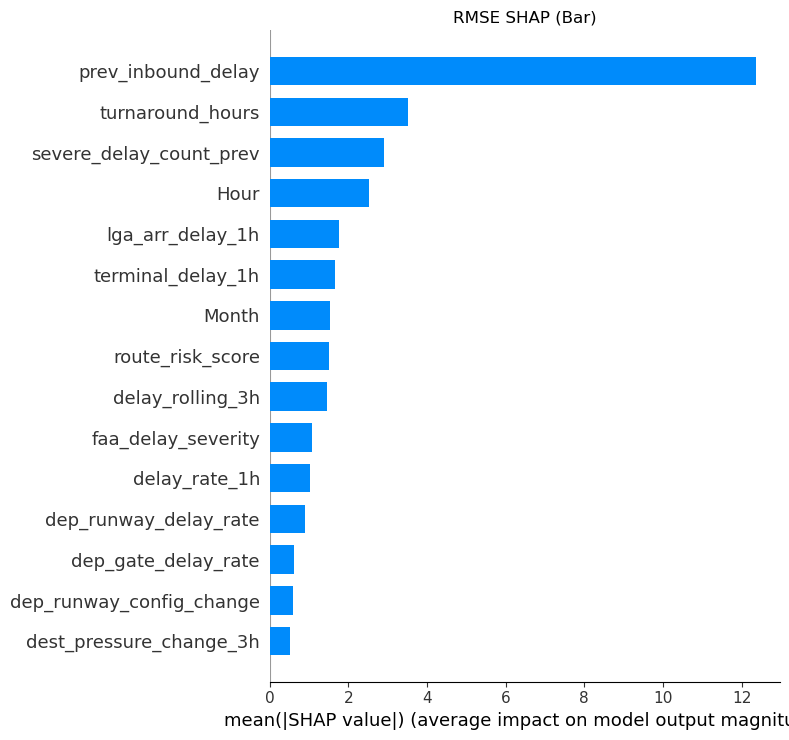

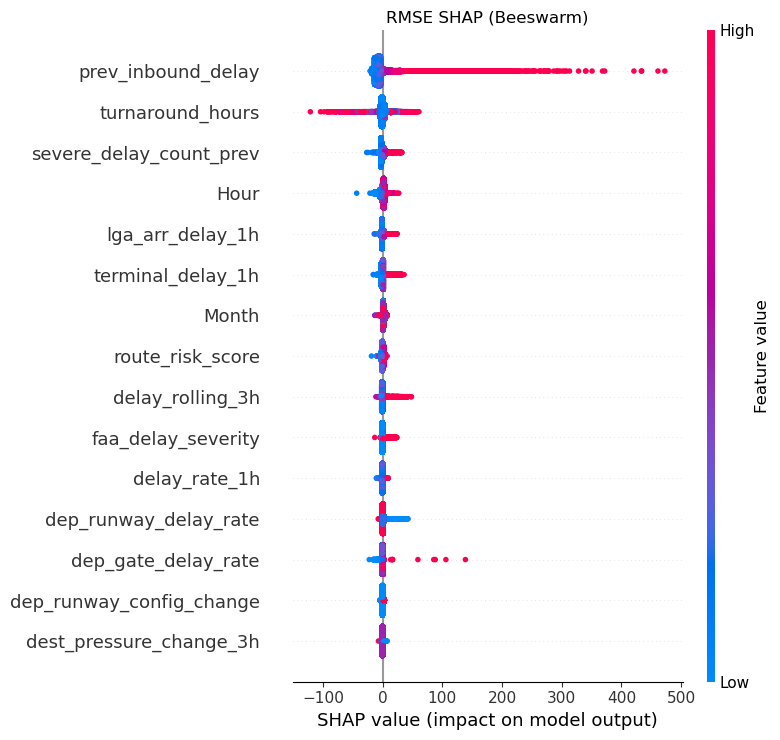

In [9]:
# 7. SHAP for RMSE model

explainer_rmse = shap.TreeExplainer(rmse_model)
shap_values_rmse = explainer_rmse.shap_values(X_test)

# Top features
mean_shap = np.abs(shap_values_rmse).mean(axis=0)
shap_ranking = sorted(zip(feature_columns, mean_shap), key=lambda x: -x[1])

print('=== RMSE SHAP Top 15 ===')
total_shap = sum(s for _, s in shap_ranking)
for i, (feat, val) in enumerate(shap_ranking[:15], 1):
    print(f'  {i:2d}. {feat:30s} {val:.4f} ({val/total_shap*100:.1f}%)')

# Plot
fig1, ax1 = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_rmse, X_test, plot_type='bar', max_display=15, show=False)
ax1.set_title('RMSE SHAP (Bar)')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_rmse, X_test, max_display=15, show=False)
ax2.set_title('RMSE SHAP (Beeswarm)')
plt.tight_layout()
plt.show()

## 9. SHAP: Q50 Model

In [10]:
# 8. SHAP for Q50 model

explainer_q50 = shap.TreeExplainer(quantile_models['Q50'])
shap_values_q50 = explainer_q50.shap_values(X_test)

mean_shap_q50 = np.abs(shap_values_q50).mean(axis=0)
shap_ranking_q50 = sorted(zip(feature_columns, mean_shap_q50), key=lambda x: -x[1])

print('=== Q50 SHAP Top 15 ===')
total_q50 = sum(s for _, s in shap_ranking_q50)
for i, (feat, val) in enumerate(shap_ranking_q50[:15], 1):
    print(f'  {i:2d}. {feat:30s} {val:.4f} ({val/total_q50*100:.1f}%)')

# RMSE vs Q50 comparison
print('\n=== RMSE vs Q50 SHAP Rank Comparison ===')
rmse_rank = {f: i+1 for i, (f, _) in enumerate(shap_ranking)}
q50_rank = {f: i+1 for i, (f, _) in enumerate(shap_ranking_q50)}
print(f'{"Feature":>30s} {"RMSE Rank":>10} {"Q50 Rank":>10} {"\u0394 Rank":>8}')
for feat, _ in shap_ranking[:15]:
    r_rank = rmse_rank.get(feat, '-')
    q_rank = q50_rank.get(feat, '-')
    delta = q_rank - r_rank if isinstance(r_rank, int) and isinstance(q_rank, int) else '-'
    if isinstance(delta, int):
        print(f'{feat:>30s} {r_rank:>10} {q_rank:>10} {delta:>+8}')
    else:
        print(f'{feat:>30s} {r_rank:>10} {q_rank:>10} {delta:>8}')

=== Q50 SHAP Top 15 ===
   1. prev_inbound_delay             12.9222 (48.1%)
   2. turnaround_hours               2.9670 (11.1%)
   3. route_risk_score               1.6710 (6.2%)
   4. delay_rolling_3h               1.1635 (4.3%)
   5. delay_rate_1h                  1.1254 (4.2%)
   6. Hour                           1.1209 (4.2%)
   7. severe_delay_count_prev        0.7885 (2.9%)
   8. dep_airline_delay_rate         0.7765 (2.9%)
   9. lga_arr_delay_1h               0.7334 (2.7%)
  10. terminal_delay_1h              0.6303 (2.3%)
  11. Month                          0.5197 (1.9%)
  12. dep_gate_delay_rate            0.5164 (1.9%)
  13. dest_historical_delay          0.4315 (1.6%)
  14. faa_delay_severity             0.3822 (1.4%)
  15. dep_runway_config_change       0.2343 (0.9%)

=== RMSE vs Q50 SHAP Rank Comparison ===
                       Feature  RMSE Rank   Q50 Rank   Δ Rank
            prev_inbound_delay          1          1       +0
              turnaround_hours          2 

## 10. Save

In [11]:
# === Save regression context for 06 (deployment) ===
import pickle
dep_regression_context = {
    'rmse_model': rmse_model,
    'quantile_models': quantile_models,
    'quantile_preds': quantile_preds,
    'pred_rmse': pred_rmse,
    'study_rmse': study_rmse,
    'use_weighted': use_weighted,
}
pickle.dump(dep_regression_context, open(DATA_PROCESSED / 'dep_regression_context.pkl', 'wb'))
print(f'Saved dep_regression_context.pkl: RMSE + {len(quantile_models)} quantile models')

Saved dep_regression_context.pkl: RMSE + 5 quantile models
